In [1]:
# =========================================
# Cell 1: Import thư viện
# =========================================
import os
import glob
import time
import json
import joblib
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

print("Đã nạp xong các thư viện.")


Đã nạp xong các thư viện.


In [2]:
# =========================================
# Cell 2: Đọc và gộp dữ liệu từ nhiều CSV 
# =========================================
import glob
import pandas as pd
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))

if not csv_files:
    DATA_DIR = Path.cwd() / "data"
    csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
    
if not csv_files:
    raise FileNotFoundError(f"Không tìm thấy file CSV nào. Đã thử tìm tại: {DATA_DIR}")

print(f"Tìm thấy {len(csv_files)} file CSV tại: {DATA_DIR}")
print("Đang gộp dữ liệu...")

df_list = []
for file in csv_files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("Kích thước dữ liệu ban đầu:", df.shape)
df.head()

Tìm thấy 8 file CSV tại: d:\hoc\ATBM HTTT\Lab 6\IDS-Logistic-Regression\data
Đang gộp dữ liệu...
Kích thước dữ liệu ban đầu: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
# =========================================
# Cell 3: Làm sạch dữ liệu và Tối ưu bộ nhớ
# =========================================
print("Kích thước dữ liệu ban đầu:", df.shape)

df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)

before_dup = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Đã xóa {before_dup - df.shape[0]} dòng trùng lặp.")

numeric_cols = df.select_dtypes(include=[np.number]).columns
zero_var_cols = df[numeric_cols].var(numeric_only=True)
zero_var_cols = zero_var_cols[zero_var_cols == 0].index.tolist()

if zero_var_cols:
    df.drop(columns=zero_var_cols, inplace=True)
    print(f"Đã xóa {len(zero_var_cols)} cột có phương sai bằng 0.")

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

print("Kích thước dữ liệu sau khi làm sạch và tối ưu:", df.shape)


Kích thước dữ liệu ban đầu: (2830743, 79)
Đã xóa 308381 dòng trùng lặp.
Đã xóa 8 cột có phương sai bằng 0.
Kích thước dữ liệu sau khi làm sạch và tối ưu: (2522362, 71)


In [4]:
# =========================================
# Cell 4: Chọn 18 đặc trưng cốt lõi (Khớp 100% Rubric PDF)
# =========================================
rename_map = {
    'Destination Port': 'Protocol',
    'Total Fwd Packets': 'Tot Fwd Pkts',
    'Total Backward Packets': 'Tot Bwd Pkts',
    'Total Length of Fwd Packets': 'TotLen Fwd Pkts',
    'Total Length of Bwd Packets': 'TotLen Bwd Pkts',
    'Fwd Packet Length Mean': 'Fwd Pkt Len Mean',
    'Bwd Packet Length Mean': 'Bwd Pkt Len Mean',
    'Flow Bytes/s': 'Flow Byts/s',
    'Flow Packets/s': 'Flow Pkts/s',
    'Packet Length Mean': 'Pkt Len Mean',
    'Packet Length Std': 'Pkt Len Std',
    'SYN Flag Count': 'SYN Flag Cnt',
    'ACK Flag Count': 'ACK Flag Cnt',
    'FIN Flag Count': 'FIN Flag Cnt',
    'RST Flag Count': 'RST Flag Cnt',
    'PSH Flag Count': 'PSH Flag Cnt',
    'URG Flag Count': 'URG Flag Cnt'
}

df.rename(columns=rename_map, inplace=True)
df.columns = df.columns.str.strip()

selected_features = [
    'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt',
    'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Cnt', 'URG Flag Cnt'
]

missing_cols = [c for c in selected_features if c not in df.columns]
if missing_cols:
    raise KeyError(f"Dữ liệu không khớp Rubric. Vẫn thiếu các cột: {missing_cols}")

if 'Label' not in df.columns:
    match_label = [c for c in df.columns if 'label' in c.lower()]
    if match_label:
        df.rename(columns={match_label[0]: 'Label'}, inplace=True)
    else:
        raise KeyError("Không tìm thấy cột Label trong dữ liệu.")

X = df[selected_features].copy()
y = df['Label'].copy()

print("-" * 30)
print("Đã thiết lập thành công 18 features chuẩn 100% theo PDF!")
print("X:", X.shape)
print("y:", y.shape)
print("Số lớp nhãn:", y.nunique())

------------------------------
Đã thiết lập thành công 18 features chuẩn 100% theo PDF!
X: (2522362, 18)
y: (2522362,)
Số lớp nhãn: 15


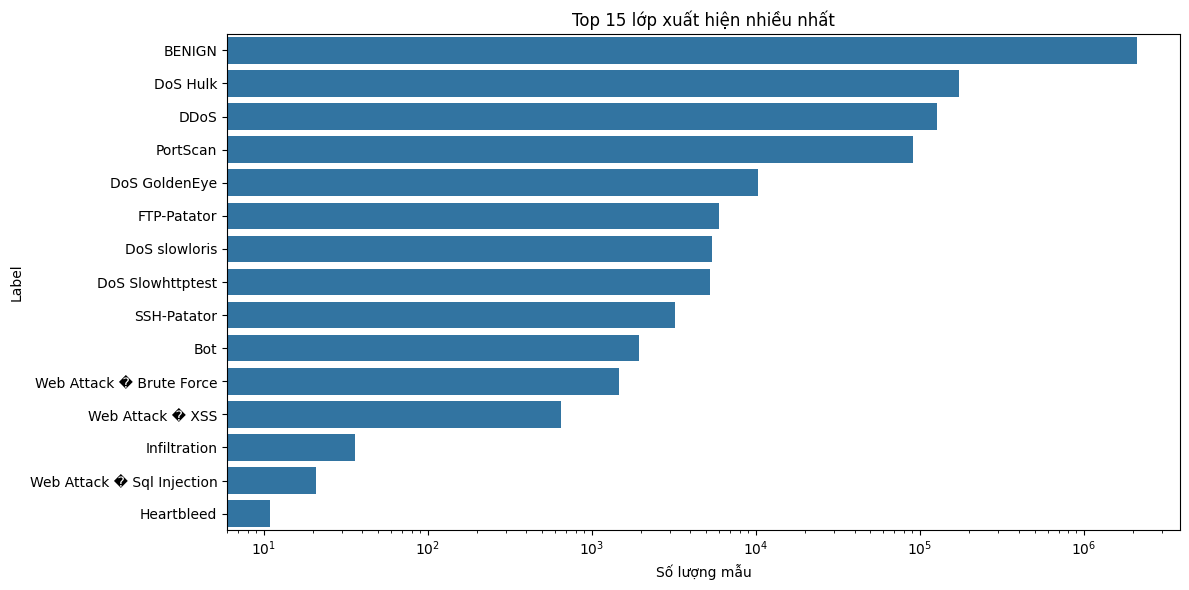

In [5]:
# =========================================
# Cell 5: EDA - Phân phối nhãn
# =========================================
plt.figure(figsize=(12, 6))
top_labels = y.value_counts().head(15)
sns.barplot(x=top_labels.values, y=top_labels.index)
plt.title("Top 15 lớp xuất hiện nhiều nhất")
plt.xlabel("Số lượng mẫu")
plt.ylabel("Label")
plt.xscale('log')
plt.tight_layout()
plt.show()


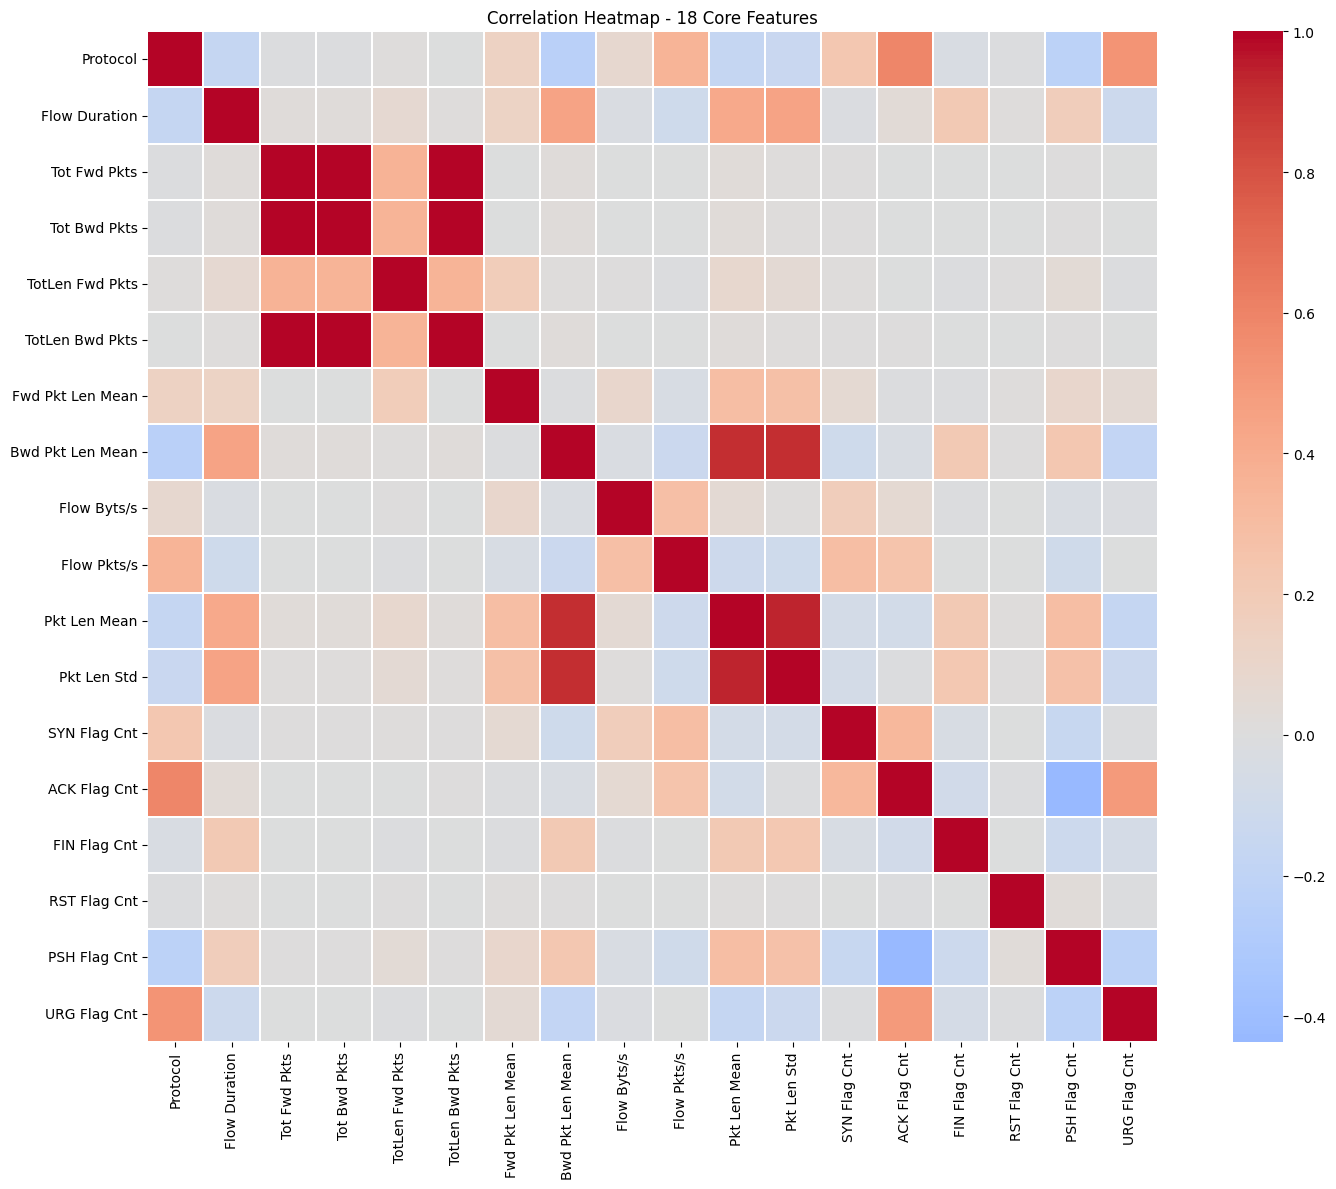

In [6]:
# =========================================
# Cell 6: EDA - Correlation Heatmap
# =========================================
plt.figure(figsize=(16, 12))
corr = df[selected_features].corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.2
)
plt.title('Correlation Heatmap - 18 Core Features')
plt.tight_layout()
plt.show()


In [7]:
# =========================================
# Cell 7: Mã hóa nhãn + chia train/test
# =========================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (2017889, 18) (2017889,)
Test : (504473, 18) (504473,)


In [14]:
# =========================================
# Cell 8: Pipeline chuẩn cho Logistic Regression
# =========================================

train_counts = Counter(y_train)
majority_class = max(train_counts, key=train_counts.get)
majority_count = train_counts[majority_class]
minority_counts = {cls: cnt for cls, cnt in train_counts.items() if cls != majority_class}

SMOTE_CAP = 30000
smote_target = min(max(int(0.1 * majority_count), 2), SMOTE_CAP)

smote_strategy = {
    cls: smote_target
    for cls, cnt in minority_counts.items()
    if 10 < cnt < smote_target
}

if not smote_strategy and minority_counts:
    smallest_class = min(minority_counts, key=minority_counts.get)
    smote_strategy = {smallest_class: minority_counts[smallest_class] + 1}

under_target = min(majority_count, max(smote_target * 2, 200000))
under_strategy = {majority_class: under_target}

print("Phân phối lớp trước cân bằng (train):")
for cls, cnt in sorted(train_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  class={cls:>2} | count={cnt}")

print(f"\nMajority class: {majority_class} | count={majority_count}")
print(f"SMOTE target   : {smote_target}")
print(f"Under target   : {under_target}")
print(f"Số lớp được SMOTE: {len(smote_strategy)}")

pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(
        sampling_strategy=smote_strategy,
        k_neighbors=1,
        random_state=42
    )),
    ('under', RandomUnderSampler(
        sampling_strategy=under_strategy,
        random_state=42
    )),
    ('clf', LogisticRegression(
        max_iter=3000,
        solver='saga',
        n_jobs=-1,
        random_state=42
    ))
])

start_time = time.time()
print("\nĐang huấn luyện mô hình với solver='saga'...")
pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"Huấn luyện xong trong {train_time:.2f} giây.")

Phân phối lớp trước cân bằng (train):
  class= 0 | count=1677187
  class= 4 | count=138279
  class= 2 | count=102413
  class=10 | count=72655
  class= 3 | count=8229
  class= 7 | count=4746
  class= 6 | count=4308
  class= 5 | count=4182
  class=11 | count=2575
  class= 1 | count=1562

Majority class: 0 | count=1677187
SMOTE target   : 30000
Under target   : 200000
Số lớp được SMOTE: 10

Đang huấn luyện mô hình với solver='saga'...
Huấn luyện xong trong 3807.86 giây.


In [15]:
# =========================================
# Cell 9: Đánh giá mô hình
# =========================================
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"Accuracy   : {acc:.4f}")
print(f"F1-macro   : {f1_macro:.4f}")
print(f"F1-weighted: {f1_weighted:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


=== KẾT QUẢ ĐÁNH GIÁ ===
Accuracy   : 0.8278
F1-macro   : 0.3316
F1-weighted: 0.8735

=== CLASSIFICATION REPORT ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.80      0.89    419297
                       Bot       0.07      0.39      0.12       391
                      DDoS       0.59      1.00      0.74     25603
             DoS GoldenEye       0.41      0.77      0.54      2057
                  DoS Hulk       0.90      0.94      0.92     34570
          DoS Slowhttptest       0.10      0.79      0.18      1046
             DoS slowloris       0.29      0.57      0.39      1077
               FTP-Patator       0.13      0.69      0.22      1187
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.01      0.71      0.01         7
                  PortScan       0.67      0.99      0.80     18164
               SSH-Patator       0.07      0.92      0.13       644

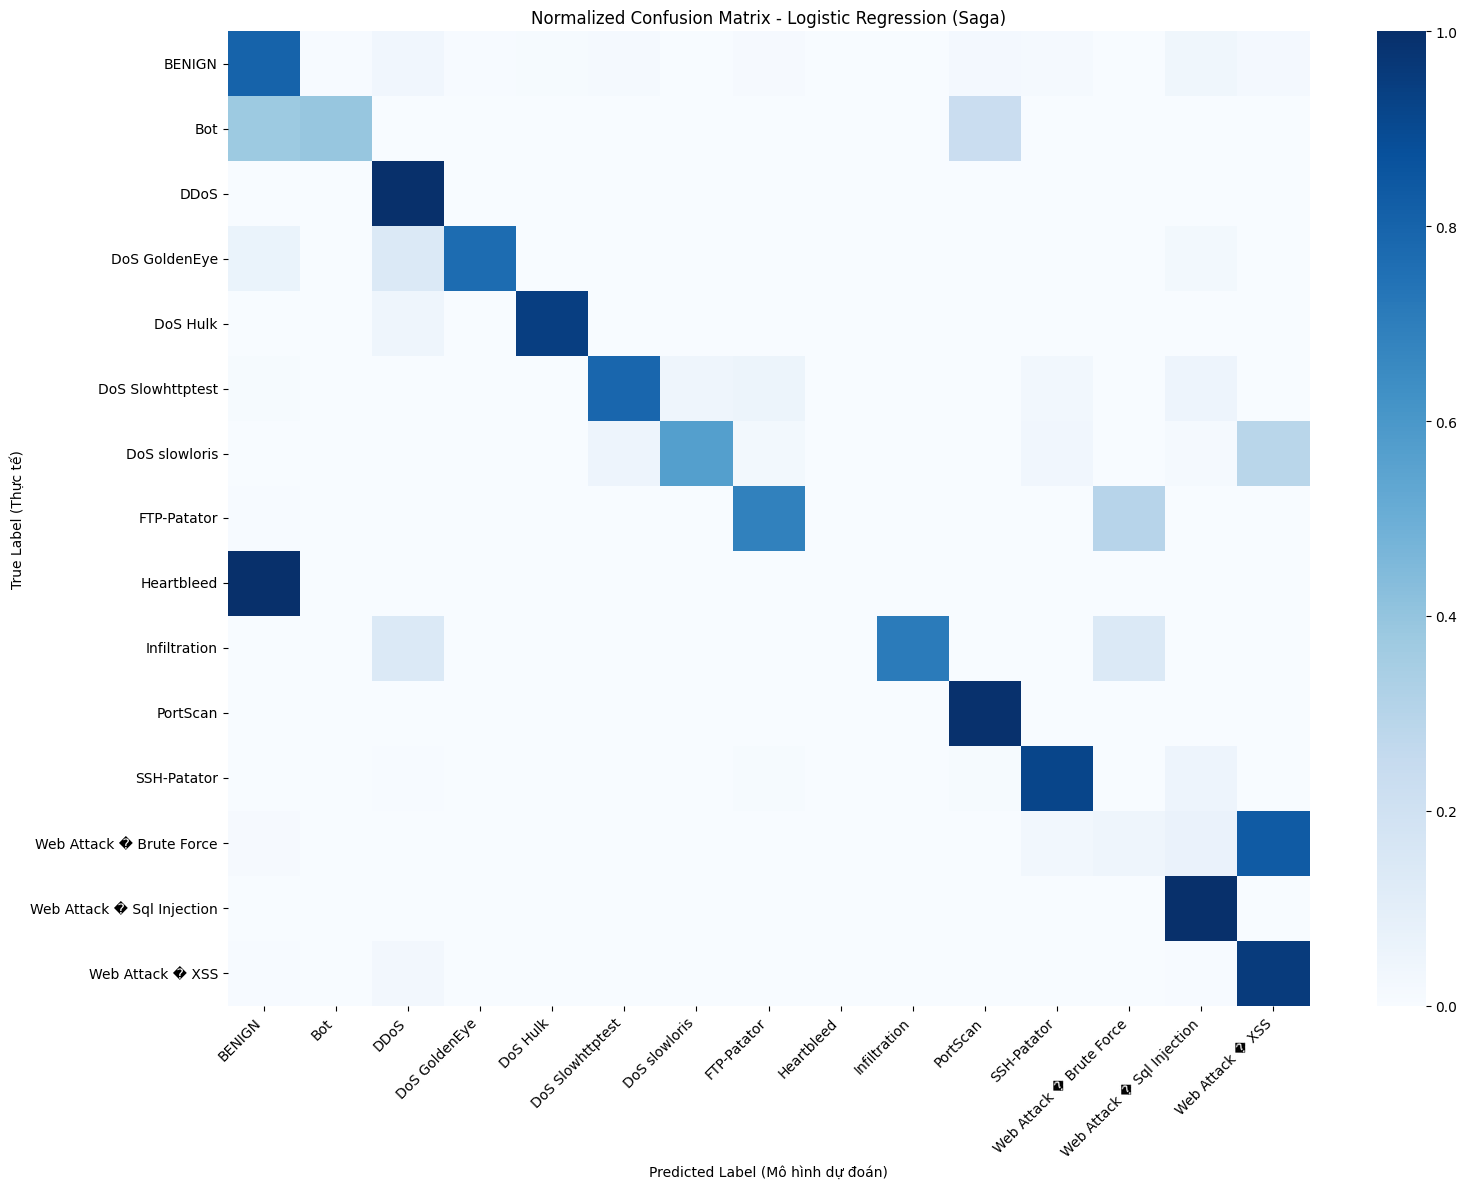

In [16]:
# =========================================
# Cell 10: Confusion Matrix
# =========================================
cm = confusion_matrix(y_test, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_normalized,
    annot=False, 
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Normalized Confusion Matrix - Logistic Regression (Saga)')
plt.xlabel('Predicted Label (Mô hình dự đoán)')
plt.ylabel('True Label (Thực tế)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [17]:
# =========================================
# Cell 11: Lưu model + metadata (Đã fix đường dẫn chuẩn xác)
# =========================================
import os
import json
import joblib
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "models"
if not (PROJECT_ROOT / "data").exists():
    MODEL_DIR = Path.cwd() / "models"
os.makedirs(MODEL_DIR, exist_ok=True)

artifact = {
    "model": pipeline,
    "label_encoder": le,
    "features": selected_features,
    "metrics": {
        "accuracy": float(acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "train_time_sec": float(train_time)
    }
}

model_path = MODEL_DIR / "ids_logistic_regression_best.pkl"
metrics_path = MODEL_DIR / "ids_logistic_regression_best_metrics.json"

joblib.dump(artifact, model_path)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(artifact["metrics"], f, ensure_ascii=False, indent=2)

print(f"Đã lưu model tại: {model_path}")
print(f"Đã lưu metrics tại: {metrics_path}")

Đã lưu model tại: d:\hoc\ATBM HTTT\Lab 6\IDS-Logistic-Regression\models\ids_logistic_regression_best.pkl
Đã lưu metrics tại: d:\hoc\ATBM HTTT\Lab 6\IDS-Logistic-Regression\models\ids_logistic_regression_best_metrics.json


In [12]:
# =========================================
# Cell 12: Hàm dự đoán 1 mẫu mới
# =========================================
def predict_one(sample_dict):
    sample_df = pd.DataFrame([sample_dict])[selected_features]
    pred_id = pipeline.predict(sample_df)[0]
    pred_label = le.inverse_transform([pred_id])[0]
    return pred_label
